In [2]:
pip install networkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 35.9 MB/s eta 0:00:00


In [1]:
#Step 1
#import libraries
import networkx as nx
import matplotlib.pyplot as plt
import ast
from networkx.algorithms import community
from collections import Counter

In [3]:
#step 2
# upload dataset
G = nx.DiGraph()

with open("congress.edgelist.txt", "r") as f:
    for line in f:
        parts = line.strip().split(maxsplit=2)

        node1, node2 = parts[0], parts[1]
        attr_dict = ast.literal_eval(parts[2])
        weight = attr_dict['weight']

        G.add_edge(node1, node2, weight=weight)

In [6]:
#step 3
# basic structure check
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Directed:", G.is_directed())

print("\nSample edges:")
for u, v, d in list(G.edges(data=True))[:5]:
    print(u, v, d)

Nodes: 475
Edges: 13289
Directed: True

Sample edges:
0 4 {'weight': 0.002105263157894737}
0 12 {'weight': 0.002105263157894737}
0 18 {'weight': 0.002105263157894737}
0 25 {'weight': 0.004210526315789474}
0 30 {'weight': 0.002105263157894737}


In [7]:
#Step 4
# degree (unweighted)
degree = dict(G.degree())
weighted_degree = dict(G.degree(weight='weight'))

print("Top Degree:", sorted(degree.items(), key=lambda x: x[1], reverse=True)[:5])
print("Top Weighted Degree:", sorted(weighted_degree.items(), key=lambda x: x[1], reverse=True)[:5])


Top Degree: [('322', 284), ('367', 261), ('393', 190), ('254', 187), ('208', 182)]
Top Weighted Degree: [('322', 2.4755004754215713), ('399', 1.3953832863227307), ('208', 1.3485508754367541), ('393', 1.2266411305548823), ('269', 1.1957225271867502)]


In [8]:
# Step 5
# Centrality Analysis
def top_k(dic, k=5):
    return sorted(dic.items(), key=lambda x: x[1], reverse=True)[:k]

deg = nx.degree_centrality(G)
bet = nx.betweenness_centrality(G)
close = nx.closeness_centrality(G)
pr = nx.pagerank(G)

print("Degree:", top_k(deg))
print("Betweenness:", top_k(bet))
print("Closeness:", top_k(close))
print("PageRank:", top_k(pr))

# weighted
bet_w = nx.betweenness_centrality(G, weight='weight')
close_w = nx.closeness_centrality(G, distance='weight')
pr_w = nx.pagerank(G, weight='weight')

print("\nWeighted Betweenness:", top_k(bet_w))
print("Weighted Closeness:", top_k(close_w))
print("Weighted PageRank:", top_k(pr_w))

Degree: [('322', 0.5991561181434598), ('367', 0.550632911392405), ('393', 0.4008438818565401), ('254', 0.3945147679324894), ('208', 0.38396624472573837)]
Betweenness: [('322', 0.07304129664896898), ('367', 0.04141240180316251), ('254', 0.0306830297688148), ('393', 0.027177654998646057), ('335', 0.017752747790576638)]
Closeness: [('322', 0.5616113744075829), ('111', 0.5537383177570093), ('208', 0.5473441108545035), ('335', 0.5417142857142857), ('269', 0.535593220338983)]
PageRank: [('322', 0.016696348346432712), ('147', 0.01284547899543367), ('389', 0.011027513079843659), ('269', 0.010660376611844975), ('215', 0.010580181938756334)]

Weighted Betweenness: [('111', 0.08450415250533001), ('322', 0.07067733561698825), ('17', 0.0676577372191149), ('428', 0.061872775443573204), ('147', 0.04995941160203744)]
Weighted Closeness: [('393', 191.17747445413985), ('242', 189.05140614856762), ('350', 188.2373264946815), ('126', 187.97436004625254), ('370', 187.83778710456005)]
Weighted PageRank: [('

In [9]:
#step 6
# Community detection
communities = list(community.greedy_modularity_communities(G))
community_list = [list(c) for c in communities]

node_community = {}
for i, comm in enumerate(community_list):
    for node in comm:
        node_community[node] = i

print("Number of communities:", len(community_list))
print("Community sizes:", Counter(node_community.values()))

Number of communities: 4
Community sizes: Counter({0: 182, 1: 173, 2: 117, 3: 3})


In [10]:
# Step 7
# Bridge Analysis
print("\n=== Community Leaders ===")

for i, comm in enumerate(community_list):
    sub = G.subgraph(comm)
    central = nx.degree_centrality(sub)
    top_nodes = sorted(central.items(), key=lambda x: x[1], reverse=True)[:3]

    print(f"\nCommunity {i}:")
    for n, s in top_nodes:
        print(n, s)

# bridges
bet = nx.betweenness_centrality(G)

bridges = []
for node, score in bet.items():
    neigh_comms = set(node_community.get(n) for n in G.neighbors(node))
    if len(neigh_comms) > 1:
        bridges.append((node, score))

print("\nTop Bridges:")
for n, s in sorted(bridges, key=lambda x: x[1], reverse=True)[:10]:
    print(n, s)



=== Community Leaders ===

Community 0:
393 0.8729281767955801
254 0.8397790055248618
367 0.8342541436464088

Community 1:
322 1.4651162790697674
208 0.9476744186046512
269 0.8837209302325582

Community 2:
17 0.7413793103448276
87 0.5431034482758621
54 0.5258620689655172

Community 3:
100 1.5
364 1.0
115 0.5

Top Bridges:
322 0.07304129664896898
367 0.04141240180316251
254 0.0306830297688148
393 0.027177654998646057
335 0.017752747790576638
208 0.016859674922057963
17 0.016458843425795636
303 0.015541875816039118
461 0.01434189545615028
113 0.012721704743944164


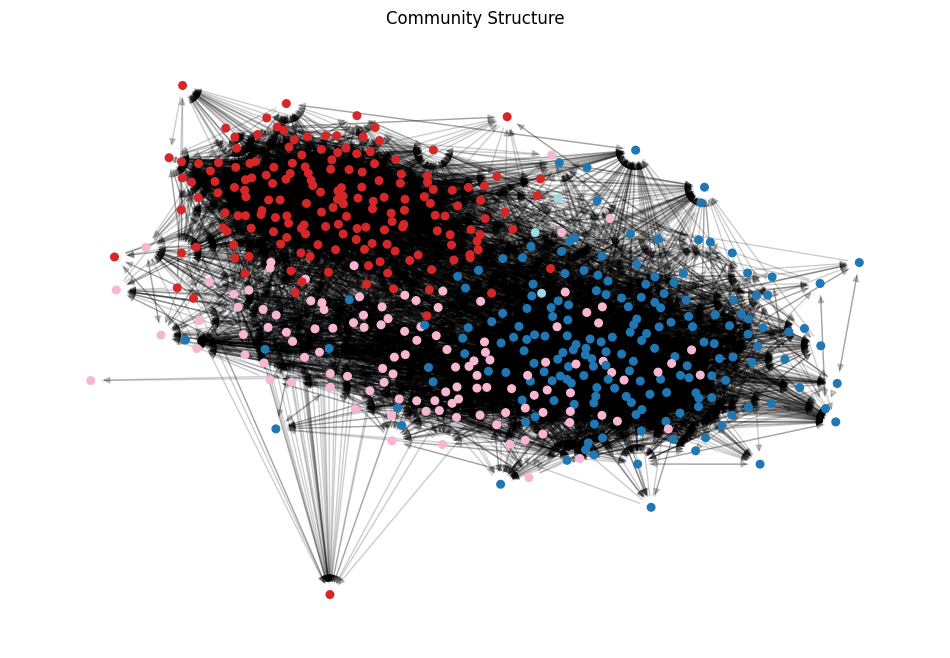

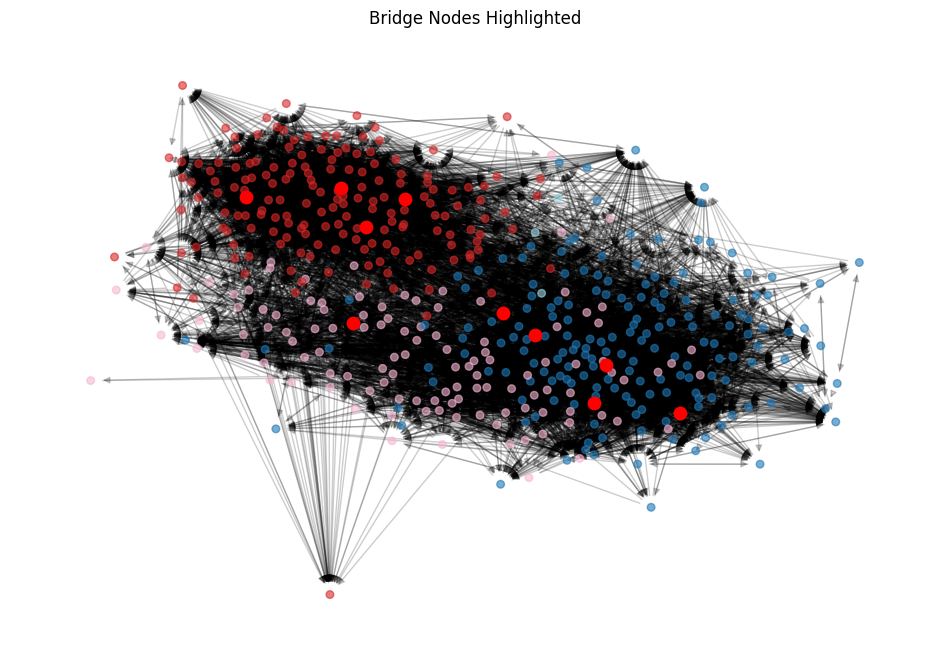

In [11]:
# step 8
# Prepare community colors
pos = nx.spring_layout(G, seed=42)

colors = [node_community[n] for n in G.nodes()]

plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.cm.tab20, node_size=30)
nx.draw_networkx_edges(G, pos, alpha=0.2)
plt.title("Community Structure")
plt.axis("off")
plt.show()

# bridge highlight
top_bridge_nodes = [n for n, _ in sorted(bet.items(), key=lambda x: x[1], reverse=True)[:10]]

plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.cm.tab20, node_size=30, alpha=0.6)
nx.draw_networkx_nodes(G, pos, nodelist=top_bridge_nodes, node_color="red", node_size=80)
nx.draw_networkx_edges(G, pos, alpha=0.2)
plt.title("Bridge Nodes Highlighted")
plt.axis("off")
plt.show()

In [12]:
# step 9
deg = nx.degree_centrality(G)
bet = nx.betweenness_centrality(G)
close = nx.closeness_centrality(G)
pr = nx.pagerank(G)

def top_k(dic, k=10):
    return sorted(dic.items(), key=lambda x: x[1], reverse=True)[:k]

print("Centrality Top Nodes:")
print(top_k(deg))
print(top_k(bet))
print(top_k(close))
print(top_k(pr))

# overlaps
top_deg = set(n for n, _ in top_k(deg))
top_bet = set(n for n, _ in top_k(bet))
top_pr = set(n for n, _ in top_k(pr))

print("\nOverlaps:")
print(len(top_deg & top_bet), "Degree vs Betweenness")
print(len(top_deg & top_pr), "Degree vs PageRank")

# community stability
comm1 = list(community.greedy_modularity_communities(G))
comm2 = list(community.greedy_modularity_communities(G))

print("\nCommunity count:", len(comm1), len(comm2))

# directed connectivity
print("\nWeak components:", len(list(nx.weakly_connected_components(G))))
print("Strong components:", len(list(nx.strongly_connected_components(G))))

# node removal test
top_bet_nodes = [n for n, _ in top_k(bet, 5)]
G2 = G.copy()
G2.remove_nodes_from(top_bet_nodes)

print("\nWeak components after removal:", len(list(nx.weakly_connected_components(G2))))


Centrality Top Nodes:
[('322', 0.5991561181434598), ('367', 0.550632911392405), ('393', 0.4008438818565401), ('254', 0.3945147679324894), ('208', 0.38396624472573837), ('303', 0.34388185654008435), ('269', 0.34388185654008435), ('190', 0.3312236286919831), ('399', 0.32067510548523204), ('111', 0.3122362869198312)]
[('322', 0.07304129664896898), ('367', 0.04141240180316251), ('254', 0.0306830297688148), ('393', 0.027177654998646057), ('335', 0.017752747790576638), ('208', 0.016859674922057963), ('17', 0.016458843425795636), ('303', 0.015541875816039118), ('461', 0.01434189545615028), ('113', 0.012721704743944164)]
[('322', 0.5616113744075829), ('111', 0.5537383177570093), ('208', 0.5473441108545035), ('335', 0.5417142857142857), ('269', 0.535593220338983), ('92', 0.5343855693348365), ('188', 0.531390134529148), ('461', 0.531390134529148), ('192', 0.5307950727883539), ('389', 0.5284280936454849)]
[('322', 0.016696348346432712), ('147', 0.01284547899543367), ('389', 0.011027513079843659),